# Joint six-dimensional emotion encoding: full regression, circular permutation, and FDR

## 1. Environment, paths, and adjustable parameters

Install the dependencies in `requirements.txt` as described in `README.md`, then open this notebook from the extracted package directory. No GPU is required. Numerical computation uses NumPy/SciPy; surface rendering uses the fsaverage5 files bundled in this package.

All windows and lags are in TR units (TR = 2 s); the HRF peak is in seconds. Anger uses the HRF branch, so its `smooth_win` does not enter the computation. `MIN_SHIFT` is the minimum circular shift of the permutations (default 30 TR).


In [1]:
from pathlib import Path
from dataclasses import dataclass
import json, sys, time, hashlib, platform, copy
from types import SimpleNamespace
import importlib.metadata as package_metadata
import pandas as pd
import numpy as np
import nibabel as nib
from scipy.signal import fftconvolve
from threadpoolctl import threadpool_limits
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from nilearn import plotting, surface
from scipy.spatial import cKDTree
from IPython.display import Image, display

def find_package_root():
    for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (candidate / "data/cache_signals_nowhiten_smooth_fwhm6_unit.npy").is_file():
            return candidate
    raise FileNotFoundError("Start this notebook from the extracted package directory or one of its subdirectories.")

ROOT = find_package_root()
ANALYSIS = ROOT / "data"
MASK = ANALYSIS / "epi_gm_mask.nii.gz"
PREDS = ANALYSIS / "preds_smoothed_danmu.npy"
DESIGN_REFERENCE = ANALYSIS / "provenance/design_june9_reference.npy"
HISTORICAL = ANALYSIS / "provenance"
REBUILD_FMRI = False  # this package starts from the preprocessed BOLD cache
USE_VERIFIED_HISTORICAL_DESIGN = False  # the rating-rebuilt matrix is used; the reference matrix is only cross-checked

def sha256_file(path):
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()

input_hashes = {str(p.relative_to(ROOT)).replace("\\", "/"): sha256_file(p)
                for p in sorted(ANALYSIS.rglob("*")) if p.is_file()}

TR, N_PERM, MIN_SHIFT, SEED, ALPHA = 2.0, 2000, 30, 42, 0.05
EMOTIONS = ["Happiness", "Surprise", "Fear", "Sadness", "Anger", "Disgust"]
MIN_R2, RADIUS_MM, VMAX = 0.018, 4.0, 0.052
# window and lag are in TR units (TR = 2 s); hrf_peak is in seconds.
# smooth_win only applies to method="lag_smooth"; HRF columns use hrf_peak and ignore smooth_win.
# transform follows the historical implementation; highpass can be highpass21 or highpass41.
JUNE9_COLUMN_CONFIG = [
    dict(transform="identity", method="lag_smooth", lag=-2, smooth_win=3, hrf_peak=None),
    dict(transform="identity", method="lag_smooth", lag=-2, smooth_win=3, hrf_peak=None),
    dict(transform="identity", method="lag_smooth", lag=-2, smooth_win=3, hrf_peak=None),
    dict(transform="highpass41", method="lag_smooth", lag=8, smooth_win=9, hrf_peak=None),
    dict(transform="highpass41", method="hrf", lag=2, smooth_win=1, hrf_peak=10.0),
    dict(transform="highpass41", method="lag_smooth", lag=-6, smooth_win=9, hrf_peak=None),
]
COLUMN_CONFIG = copy.deepcopy(JUNE9_COLUMN_CONFIG)
# Customization example (uncomment, then rerun all cells):
# COLUMN_CONFIG[0]["smooth_win"] = 5
# COLUMN_CONFIG[3]["lag"] = 6
assert len(COLUMN_CONFIG) == 6
assert all(isinstance(c["lag"], int) and isinstance(c["smooth_win"], int)
           and c["smooth_win"] >= 1 for c in COLUMN_CONFIG)
assert N_PERM > 0 and MIN_SHIFT >= 1 and 0 < ALPHA < 1
is_june9_design = COLUMN_CONFIG == JUNE9_COLUMN_CONFIG and TR == 2.0
is_june9_statistics = is_june9_design and (N_PERM, MIN_SHIFT, SEED, ALPHA) == (2000, 30, 42, .05)
run_config = dict(columns=COLUMN_CONFIG, TR=TR, N_PERM=N_PERM, MIN_SHIFT=MIN_SHIFT,
                  SEED=SEED, ALPHA=ALPHA, REBUILD_FMRI=REBUILD_FMRI,
                  MIN_R2=MIN_R2, RADIUS_MM=RADIUS_MM, historical_colorbar_max=VMAX,
                  permutation="shared_signed_circular_shift", implementation="june9_portable_handoff_v1", input_sha256=input_hashes)
run_id = hashlib.sha256(json.dumps(run_config, sort_keys=True).encode()).hexdigest()[:12]
OUT_DIR = ROOT / "results" / run_id
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "run_config.json").write_text(json.dumps(run_config, indent=2), encoding="utf-8")
display(pd.DataFrame(COLUMN_CONFIG, index=EMOTIONS).assign(lag_seconds=[c["lag"]*TR for c in COLUMN_CONFIG]))
threadpool_limits(limits=4, user_api="blas")
print("Output directory:", OUT_DIR.relative_to(ROOT))
print(f"permutations={N_PERM}, seed={SEED}, min shift={MIN_SHIFT} TR")

,transform,method,lag,smooth_win,hrf_peak,lag_seconds
Happiness,identity,lag_smooth,-2,3,NaN,-4.0
Surprise,identity,lag_smooth,-2,3,NaN,-4.0
Fear,identity,lag_smooth,-2,3,NaN,-4.0
Sadness,highpass41,lag_smooth,8,9,NaN,16.0
Anger,highpass41,hrf,2,1,10.0,4.0
Disgust,highpass41,lag_smooth,-6,9,NaN,-12.0


Output directory: results\0f138fe1388b
permutations=2000, seed=42, min shift=30 TR


## 2. Load the BOLD cache and gray-matter voxel coordinates

The input is the **non-prewhitened, 6 mm FWHM spatially smoothed** BOLD cache actually used by the historical regression. The cache was extracted with the gray-matter mask, column-centered, and L2-normalized; the re-centering here follows the original implementation. No additional smoothing or whitening is applied.

`cache_mask_coords.npy`, the volume shape, the affine, and the NIfTI mask are used to verify the spatial order of the 43,783 columns. This package does not include the ~935 MB upstream 4D image; the original cache extraction method is kept in `data/provenance/scan_nowhiten_lag_candidates.py` for reference and is not a runtime dependency.


In [2]:
cache_y_path = ANALYSIS / "cache_signals_nowhiten_smooth_fwhm6_unit.npy"
coords = np.load(ANALYSIS / "cache_mask_coords.npy")
vol_shape = tuple(np.load(ANALYSIS / "cache_vol_shape.npy").tolist())
affine = np.load(ANALYSIS / "cache_affine.npy")
mask_img = nib.load(str(MASK))
assert mask_img.shape == vol_shape
assert np.allclose(mask_img.affine, affine)
assert np.array_equal(np.asarray(np.where(mask_img.get_fdata() > 0)), coords)

Y = np.load(cache_y_path).astype(np.float32)

T, V = Y.shape
assert coords.shape == (3, V)
assert np.isfinite(Y).all()
Yc = Y - Y.mean(0, keepdims=True)
del Y
ss_tot = np.einsum("tv,tv->v", Yc, Yc).astype(np.float32)
ss_tot[ss_tot <= 0] = 1.0
print(f"time points T={T}; gray-matter voxels V={V}; Yc={Yc.shape}")

time points T=3595; gray-matter voxels V=43783; Yc=(3595, 43783)


## 3. Build the design matrix X from the emotion series

The 3599 raw rating rows are first truncated to the 3595 fMRI rows and **then** transformed, so edge handling stays consistent. The historical analysis scripts used the column names Happiness, Surprise, Fear, Sadness, Anger, Disgust in that order; the NPY file itself carries no column labels, so this notebook follows the historical naming without independently proving the upstream label order.

| Emotion | Transform | Lag | Smoothing / HRF |
|---|---|---:|---|
| Happiness / Surprise / Fear | identity | -2 TR | 3 TR moving average |
| Sadness | highpass41 | +8 TR | 9 TR moving average |
|Anger|highpass41|+2 TR|HRF peak=10 s|
| Disgust | highpass41 | -6 TR | 9 TR moving average |

highpass41 subtracts the 41 TR moving average; a positive lag shifts the series later with edge replication. This differs from the circular shifts used in the permutations below. The functions keep the historical standardization and boundary rules.

The table above lists the default historical parameters: 3 TR = 6 s, 9 TR = 18 s, 41 TR = 82 s. All parameters are adjusted centrally in COLUMN_CONFIG above.

**This configuration was chosen because it yields the largest number of significant voxels; other configurations also produce significant voxels, but far fewer. It is the best configuration found through repeated experiments.**

In [3]:
@dataclass(frozen=True)
class Combo:
    transform: str
    method: str  # lag_smooth | hrf
    lag: int
    smooth_win: int
    hrf_peak: float | None

def moving_average(x: np.ndarray, win: int) -> np.ndarray:
    if win <= 1:
        return x.copy()
    kernel = np.ones(win, dtype=np.float64) / float(win)
    return np.convolve(x, kernel, mode="same")

def apply_lag(x: np.ndarray, lag: int) -> np.ndarray:
    if lag == 0:
        return x.copy()
    y = np.roll(x, lag)
    if lag > 0:
        y[:lag] = y[lag]
    else:
        y[lag:] = y[lag - 1]
    return y

def spm_hrf_like(
    tr: float,
    peak: float = 6.0,
    undershoot: float = 16.0,
    peak_disp: float = 1.0,
    undershoot_disp: float = 1.0,
    p_u_ratio: float = 6.0,
    duration: float = 32.0,
    oversampling: int = 16,
) -> np.ndarray:
    from scipy.stats import gamma

    dt = tr / oversampling
    t = np.arange(0.0, duration, dt)
    g1 = gamma.pdf(t, peak / peak_disp, scale=peak_disp)
    g2 = gamma.pdf(t, undershoot / undershoot_disp, scale=undershoot_disp)
    h = g1 - g2 / p_u_ratio
    h = h[::oversampling]
    h = h / (h.sum() + 1e-12)
    return h.astype(np.float64)

def transform_series(x: np.ndarray, name: str) -> np.ndarray:
    x = x.astype(np.float64)
    if name == "identity":
        y = x
    elif name == "sqrt":
        y = np.sqrt(np.clip(x, 0.0, None))
    elif name == "log1p":
        y = np.log1p(np.clip(x, 0.0, None))
    elif name == "square":
        y = x * x
    elif name == "diff":
        y = np.concatenate([[0.0], np.diff(x)])
    elif name == "diff_abs":
        y = np.concatenate([[0.0], np.abs(np.diff(x))])
    elif name == "highpass21":
        y = x - moving_average(x, 21)
    elif name == "highpass41":
        y = x - moving_average(x, 41)
    elif name == "spike_q90":
        thr = float(np.quantile(x, 0.90))
        y = (x >= thr).astype(np.float64)
    elif name == "spike_q95":
        thr = float(np.quantile(x, 0.95))
        y = (x >= thr).astype(np.float64)
    else:
        raise ValueError(f"Unknown transform: {name}")

    y = y - y.mean()
    std = y.std()
    if std > 1e-10:
        y = y / std
    return y.astype(np.float32)

def build_column(
    raw_col: np.ndarray,
    combo: Combo,
    tr: float,
    out_len: int,
) -> np.ndarray:
    x = transform_series(raw_col, combo.transform)
    if combo.method == "lag_smooth":
        x = moving_average(x, combo.smooth_win)
        x = apply_lag(x, combo.lag)
        x = x[:out_len]
    elif combo.method == "hrf":
        if combo.hrf_peak is None:
            raise ValueError("HRF combo missing hrf_peak.")
        h = spm_hrf_like(tr=tr, peak=combo.hrf_peak)
        x = fftconvolve(x, h, mode="full")[:out_len]
        x = apply_lag(x, combo.lag)
    else:
        raise ValueError(f"Unknown method: {combo.method}")

    x = x - x.mean()
    std = x.std()
    if std > 1e-10:
        x = x / std
    return x.astype(np.float32)

In [4]:
raw = np.load(PREDS).astype(np.float32)
assert raw.ndim == 2 and raw.shape[1] == 6 and raw.shape[0] >= T
raw = raw[:T]
assert 2 * MIN_SHIFT <= T
assert all(c["smooth_win"] <= T and abs(c["lag"]) < T for c in COLUMN_CONFIG)
combos = [Combo(**c) for c in COLUMN_CONFIG]
rebuilt_X = np.column_stack([build_column(raw[:, i], c, TR, T) for i, c in enumerate(combos)])
np.save(OUT_DIR / "rebuilt_design.npy", rebuilt_X)
reference_X = np.load(DESIGN_REFERENCE).astype(np.float32)[:T]
design_error = np.max(np.abs(rebuilt_X - reference_X), axis=0)
if is_june9_design:
    assert np.array_equal(rebuilt_X, reference_X), design_error
X_raw = rebuilt_X.copy()
assert np.isfinite(X_raw).all() and X_raw.shape == (T, 6)
assert np.linalg.matrix_rank(X_raw - X_raw.mean(0)) == 6
print("is historical design config:", is_june9_design)
print("max abs difference vs historical matrix per column:", dict(zip(EMOTIONS, design_error.tolist())))

is historical design config: True
max abs difference vs historical matrix per column: {'Happiness': 0.0, 'Surprise': 0.0, 'Fear': 0.0, 'Sadness': 0.0, 'Anger': 0.0, 'Disgust': 0.0}


## 4. Joint six-emotion OLS regression and R²

For each voxel we fit $Y_v = X\beta_v + \epsilon_v$ with all six columns entering the model together. X is standardized and re-centered and Y is centered, which is equivalent to fitting an intercept.

$\hat\beta=(X^TX)^+X^TY$; $R_v^2=1-SS_{res,v}/SS_{tot,v}$. The original script uses the equivalent projection sum-of-squares formula to save memory. This notebook keeps the original algorithm, saves the coefficients under the standardized design / unit-norm BOLD, and verifies both formulas against explicit predictions on a subset of voxels.


In [5]:
def zscore(X):
    X = X.astype(np.float32); X -= X.mean(0, keepdims=True)
    s = X.std(0, keepdims=True); s[s == 0] = 1.0
    return X / s

def fit_joint(X, Yc, ss_tot):
    X = zscore(X); X -= X.mean(0, keepdims=True)
    inv = np.linalg.pinv(X.T @ X).astype(np.float32)
    xty = (X.T @ Yc).astype(np.float32)
    pred = np.einsum("pv,pq,qv->v", xty, inv, xty, optimize=True)
    return np.clip(pred / ss_tot, 0, 1).astype(np.float32)

def bh(p):
    n = p.size; order = np.argsort(p); q = np.empty(n, np.float32); c = 1.0
    for i in range(n - 1, -1, -1):
        c = min(c, float(p[order[i]]) * n / (i + 1)); q[order[i]] = c
    return np.clip(q, 0, 1)

def save_nii(flat, path, coords, shape, affine):
    vol = np.zeros(shape, np.float32); vol[coords[0], coords[1], coords[2]] = flat
    nib.save(nib.Nifti1Image(vol, affine), str(path))

In [6]:
obs_r2 = fit_joint(X_raw, Yc, ss_tot)
X = zscore(X_raw)
X -= X.mean(0, keepdims=True)
betas = (np.linalg.pinv(X.T @ X).astype(np.float32) @ (X.T @ Yc)).astype(np.float32)
check_voxels = np.linspace(0, V-1, 12, dtype=int)
pred_check = X @ betas[:, check_voxels]
explicit_r2 = 1 - np.sum((Yc[:, check_voxels] - pred_check)**2, axis=0) / ss_tot[check_voxels]
assert np.allclose(obs_r2[check_voxels], explicit_r2, atol=2e-5)
np.save(OUT_DIR / "joint_beta_standardized.npy", betas)
print(f"joint model max R²={obs_r2.max():.9f}")

joint model max R²=0.074995749


## 5. Circular permutation: all six columns shifted together, refit each time

Y is fixed while the whole X is circularly shifted along time by the same amount, preserving the correspondence among the six emotions and the temporal structure of each column. Shifts are drawn with replacement from `[30, T-30]` with signs drawn independently, exactly following the historical RNG order.

After each shift the design is re-standardized and the joint regression is refit, comparing $R^2_{perm,v}\ge R^2_{obs,v}$. The empirical p value uses the plus-one correction: $p_v=(1+\#\{R^2_{perm,v}\ge R^2_{obs,v}\})/(2000+1)$.

The cell below actually runs all 2,000 permutations. It saves the shift list, the exceedance counts, and the null distribution of the peak-R² voxel, but not the huge voxel × permutation result matrix.

In [7]:
rng = np.random.default_rng(SEED)
valid_shifts = np.arange(MIN_SHIFT, T - MIN_SHIFT + 1)
shifts = rng.choice(valid_shifts, size=N_PERM, replace=True) * rng.choice([-1, 1], size=N_PERM)
np.save(OUT_DIR / "permutation_shifts.npy", shifts)
counts = np.ones(V, dtype=np.int64)
peak_voxel = int(np.argmax(obs_r2))
peak_null_r2 = np.empty(N_PERM, dtype=np.float32)
start_time = time.perf_counter()
for i, shift in enumerate(shifts):
    null_r2 = fit_joint(np.roll(X_raw, int(shift), axis=0), Yc, ss_tot)
    counts += (null_r2 >= obs_r2).astype(np.int64)
    peak_null_r2[i] = null_r2[peak_voxel]
    if (i+1) % 100 == 0:
        print(f"{i+1}/{N_PERM}, elapsed {time.perf_counter()-start_time:.1f} s", flush=True)
p_perm = counts.astype(np.float32) / (N_PERM + 1)
np.savez_compressed(OUT_DIR / "permutation_audit.npz", counts=counts,
                    shifts=shifts, peak_voxel=peak_voxel, peak_null_r2=peak_null_r2)
print("Permutations done. Minimum empirical p value:", float(p_perm.min()))

100/2000, elapsed 7.5 s


200/2000, elapsed 15.0 s


300/2000, elapsed 22.4 s


400/2000, elapsed 29.8 s


500/2000, elapsed 37.3 s


...

1700/2000, elapsed 126.5 s


1800/2000, elapsed 133.8 s


1900/2000, elapsed 141.4 s


2000/2000, elapsed 148.9 s


Permutations done. Minimum empirical p value: 0.0004997501382604241


## 6. Whole-brain BH-FDR and NIfTI output
BH-FDR is applied to the empirical p values of all gray-matter voxels together, without ROI grouping or R² pre-screening. The statistical threshold q<0.05 is handled separately from the display threshold R²≥0.018 used later for plotting.

In [8]:
q_perm = bh(p_perm)
n_sig = int((q_perm < ALPHA).sum())
peak = float(obs_r2[q_perm < ALPHA].max()) if n_sig else 0.0
for name, values in {
    "joint_r2": obs_r2, "joint_pvals": p_perm, "joint_qvals": q_perm,
    "joint_r2_sig_q005": np.where(q_perm < ALPHA, obs_r2, 0).astype(np.float32),
}.items():
    save_nii(values, OUT_DIR / f"{name}.nii.gz", coords, vol_shape, affine)
for i, emotion in enumerate(EMOTIONS):
    save_nii(betas[i], OUT_DIR / f"beta_{emotion}.nii.gz", coords, vol_shape, affine)
summary = dict(model="joint 6-emotion OLS", T=T, V=V, prewhitening="none",
               n_perm=N_PERM, min_shift_TR=MIN_SHIFT, seed=SEED, alpha=ALPHA,
               n_sig_voxels=n_sig, peak_r2=peak, design_error=design_error.tolist(),
               rebuilt_fmri=REBUILD_FMRI, use_verified_historical_design=USE_VERIFIED_HISTORICAL_DESIGN)
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(8*1024*1024), b""):
            h.update(block)
    return h.hexdigest()
summary["inputs"] = input_hashes
summary["run_config"] = run_config
summary["is_june9_statistics"] = is_june9_statistics
summary["versions"] = {"python": platform.python_version(), **{name: package_metadata.version(name) for name in ["numpy", "scipy", "pandas", "nibabel", "nilearn", "matplotlib", "threadpoolctl"]}}
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"BH-FDR q<{ALPHA}: {n_sig} significant voxels; peak R²={peak:.9f}")
(ROOT / "results/latest_run.json").write_text(json.dumps({"run_id": run_id, "result_dir": str(OUT_DIR.relative_to(ROOT)).replace("\\", "/")}, indent=2), encoding="utf-8")


BH-FDR q<0.05: 3981 significant voxels; peak R²=0.074995749


70

## 7. Cross-check against the historical panel-c statistical inputs
The old statistical maps are used only here for comparison and do not enter the regression, permutation, or FDR computations above. Numerical error, significant-voxel count, and significance-mask agreement are reported separately.

In [9]:
old_r2 = nib.load(str(HISTORICAL / "joint_r2.nii.gz")).get_fdata()[tuple(coords)]
old_q = nib.load(str(HISTORICAL / "joint_qvals.nii.gz")).get_fdata()[tuple(coords)]
comparison = {
    "max_abs_r2_error": float(np.max(np.abs(obs_r2 - old_r2))),
    "max_abs_q_error": float(np.max(np.abs(q_perm - old_q))),
    "significance_mask_equal": bool(np.array_equal(q_perm < ALPHA, old_q < ALPHA)),
    "historical_n_sig": int((old_q < ALPHA).sum()), "new_n_sig": n_sig,
}
(OUT_DIR / "historical_comparison.json").write_text(json.dumps(comparison, indent=2), encoding="utf-8")
print(json.dumps(comparison, indent=2))

{
  "max_abs_r2_error": 2.2351741790771484e-07,
  "max_abs_q_error": 0.0014314055442810059,
  "significance_mask_equal": true,
  "historical_n_sig": 3981,
  "new_n_sig": 3981
}


## 8. Example permutation null distribution
This shows the permutation distribution of the voxel with the highest observed R², purely to illustrate the testing procedure; it does not replace whole-brain FDR.

This voxel is selected by the maximum observed R²; the histogram is only a workflow example, not an independent validation, nor the permutation distribution of the whole-brain maximum statistic.

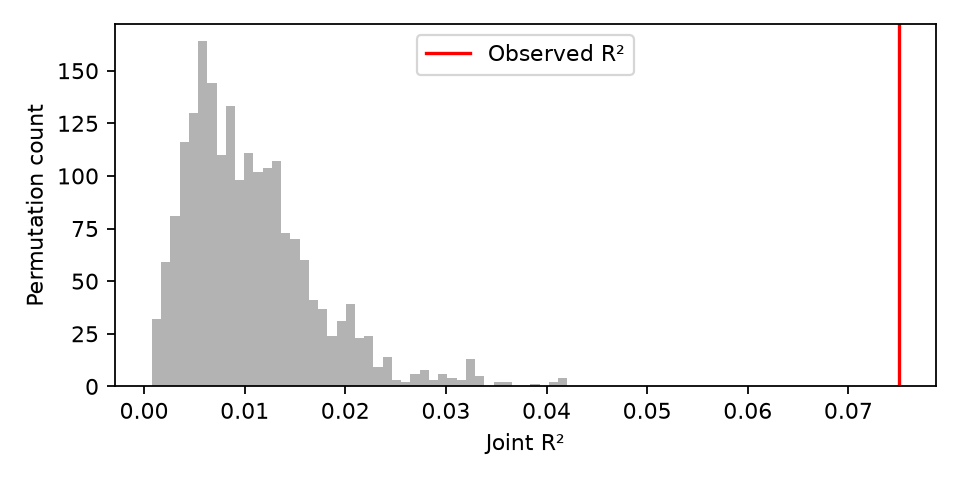

In [10]:
fig_null, ax = plt.subplots(figsize=(6, 3))
ax.hist(peak_null_r2, bins=45, color="0.7")
ax.axvline(obs_r2[peak_voxel], color="red", label="Observed R²")
ax.set(xlabel="Joint R²", ylabel="Permutation count")
ax.legend()
fig_null.tight_layout()
fig_null.savefig(OUT_DIR / "peak_voxel_null_distribution.png", dpi=160)
plt.close(fig_null)
display(Image(filename=str(OUT_DIR / "peak_voxel_null_distribution.png")))

## 9. Project the significant voxels onto the surface

After the whole-gray-matter statistical test, voxels with `q<0.05` and `R²≥0.018` are projected onto the fsaverage5 pial surface within a 4 mm neighborhood, taking the neighborhood maximum, and displayed on the inflated surface. The left/right lateral views follow the original panel c.

Each surface value is the maximum R² of nearby significant voxels; it is not a newly fitted vertex-wise R² and does not represent a regional average. The 4 mm projection may miss voxels far from the cortex; the full results are in `joint_r2.nii.gz` and `joint_qvals.nii.gz`.


In [11]:
RES_DIR = OUT_DIR
OUT_PNG = OUT_DIR / "danmu6_highpass_fig1c_nolabel.png"
r2img = nib.load(str(RES_DIR / "joint_r2.nii.gz"))
q     = nib.load(str(RES_DIR / "joint_qvals.nii.gz")).get_fdata()
r2    = r2img.get_fdata(dtype=np.float32)
sig   = (q < ALPHA) & (r2 > 0) & (r2 >= MIN_R2)
data  = np.where(sig, r2, 0.0).astype(np.float32)
n_sig = int(((q < ALPHA) & (r2 > 0)).sum())
img   = nib.Nifti1Image(data, r2img.affine)
assert r2.shape == q.shape
assert np.allclose(r2img.affine, nib.load(str(RES_DIR / "joint_qvals.nii.gz")).affine)
peak_r2 = float(np.max(r2[(q < ALPHA) & (r2 > 0)])) if n_sig else 0.0
print(f"significant voxels: {n_sig}; displayed voxels: {int(sig.sum())}; peak significant R²: {peak_r2:.6f}")

significant voxels: 3981; displayed voxels: 3981; peak significant R²: 0.074996


In [12]:
def red_cmap():
    base = LinearSegmentedColormap.from_list(
        "wr", ["#fefaf8", "#f8d9c7", "#f3b08d", "#ea7b50", "#d8432f", "#9d0c16"], N=256)
    return LinearSegmentedColormap.from_list("wr_g", base(np.linspace(0, 1, 256) ** 0.55), N=256)

def bg(fs):
    out = []
    for p in (fs.sulc_left, fs.sulc_right):
        v = surface.load_surf_data(p).astype(np.float32)
        v = (v - v.min()) / (v.max() - v.min() + 1e-6)
        out.append((0.12 + 0.10 * v).astype(np.float32))
    return out

def peak_texture(img, data, pial_mesh):
    mesh = surface.load_surf_mesh(pial_mesh)
    tex  = np.zeros(mesh.coordinates.shape[0], np.float32)
    vox  = np.column_stack(np.where(data > 0))
    if vox.size == 0:
        return tex
    coords = nib.affines.apply_affine(img.affine, vox)
    vals   = data[tuple(vox.T)]
    tree   = cKDTree(coords)
    for i, nb in enumerate(tree.query_ball_point(mesh.coordinates, r=RADIUS_MM)):
        if nb:
            tex[i] = float(np.max(vals[nb]))
    return tex

In [13]:
fs = SimpleNamespace(**{name: str(ROOT / "data/fsaverage5" / f"{name}.gii.gz")
                        for name in ["pial_left", "pial_right", "infl_left", "infl_right", "sulc_left", "sulc_right"]})
bg_l, bg_r = bg(fs)
cmap = red_cmap()
tex_l = peak_texture(img, data, fs.pial_left)
tex_r = peak_texture(img, data, fs.pial_right)
print(f"left/right hemisphere vertex counts: {tex_l.size}, {tex_r.size}")

left/right hemisphere vertex counts: 10242, 10242


## 10. Main figure: color bar spans the true significant peak

The color-bar maximum of the main figure is the maximum significant R² of this run (about 0.075 with the default results).

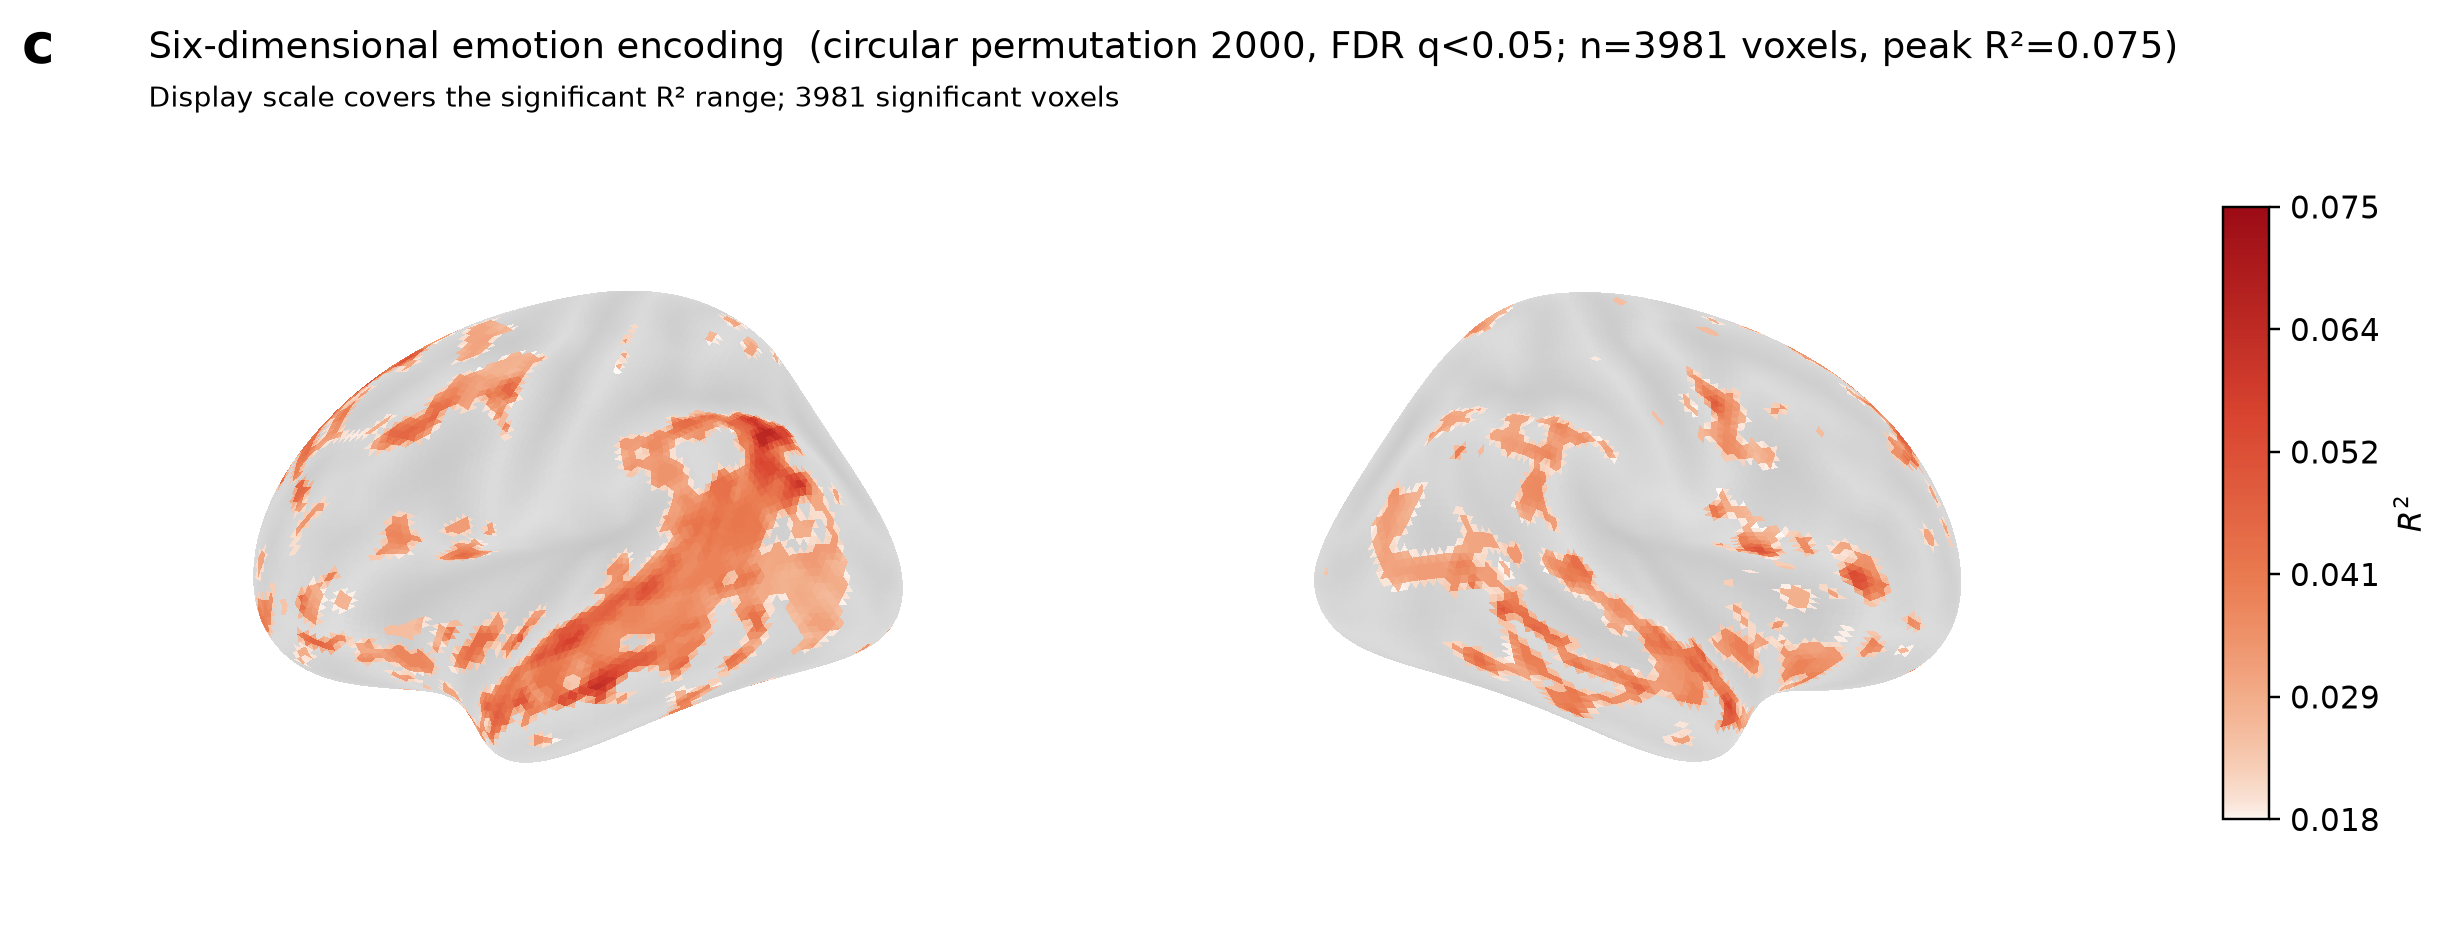

Saved: results\0f138fe1388b\joint_6d_surface_actual_r2.png


In [14]:
actual_vmax = max(peak_r2, MIN_R2 + .001)
fig = plt.figure(figsize=(11.5, 4.8), facecolor="white")
grid = fig.add_gridspec(1, 2, left=0.03, right=0.86, top=0.84, bottom=0.10, wspace=0.02)
axes = {}
for col, (hemi, mesh, tex, bgm) in enumerate([
    ("left",  fs.infl_left,  tex_l, bg_l),
    ("right", fs.infl_right, tex_r, bg_r),
]):
    ax = fig.add_subplot(grid[0, col], projection="3d")
    plotting.plot_surf_stat_map(
        mesh, tex, hemi=hemi, view="lateral", bg_map=bgm, bg_on_data=False,
        cmap=cmap, vmin=MIN_R2, vmax=actual_vmax,
        threshold=float(np.nextafter(MIN_R2, 0.0)),
        alpha=1.0, colorbar=False, figure=fig, axes=ax)
    ax.set_axis_off()
    axes[hemi] = ax

cax = fig.add_axes([0.89, 0.20, 0.018, 0.58])
sm = plt.cm.ScalarMappable(norm=Normalize(MIN_R2, actual_vmax), cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, cax=cax); cb.set_label(r"$R^2$")
ticks = np.linspace(MIN_R2, actual_vmax, 6)
cb.set_ticks(ticks)
cb.set_ticklabels([f"{t:.3f}" for t in ticks])

fig.text(0.02, 0.93, "c", fontsize=18, fontweight="bold", ha="left", va="center")
fig.text(0.07, 0.93,
         f"Six-dimensional emotion encoding  (circular permutation {N_PERM}, FDR q<{ALPHA}; "
         f"n={n_sig} voxels, peak R²={peak_r2:.3f})",
         fontsize=12, ha="left", va="center")
fig.text(.07, .875, f"Display scale covers the significant R² range; {n_sig} significant voxels", fontsize=9)
actual_path = OUT_DIR / "joint_6d_surface_actual_r2.png"
fig.savefig(actual_path, dpi=220, facecolor="white", bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(actual_path)))
print("Saved:", actual_path.relative_to(ROOT))